In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- - - - -  CONFIGURACIÓN ---
FILE_NAME = 'df_0_corrected.csv'
NDC_MEDIAN = 4.66
COLUMNA_EXPECTATIVA = 'expectativa_sin'
VALOR_EXPECTATIVA = 1  # El valor específico que quieres analizar (ej: 1)
orden_tratos = ['CON','SIN', 'DIST']
# --- CARGA DE DATOS ---
df = pd.read_csv(FILE_NAME)

# --- FUNCIONES ---
def classify_ndc(score):
    """Clasifica el puntaje NDC en High o Low según la mediana."""
    if pd.isna(score): return 'Unknown'
    return 'High NDC' if score > NDC_MEDIAN else 'Low NDC'

In [3]:
# --- PREPROCESAMIENTO GENERAL ---

# 1. Crear DataFrame de Sujetos Únicos (df_u)
df_u = df.drop_duplicates(subset=['ID_Sujeto']).copy()

# 2. Limpieza y Creación de Variables (NDC y Tratamiento)
# Asegurar que NDC_Score sea numérico
df_u['NDC_Score'] = pd.to_numeric(df_u['NDC_Score'], errors='coerce')

# Aplicar clasificación NDC
df_u['NDC_Group'] = df_u['NDC_Score'].apply(classify_ndc)

# Mapear el grupo al dataframe largo (df) usando ID_Sujeto para tenerlo disponible allí también
ndc_map = df_u.set_index('ID_Sujeto')['NDC_Group'].to_dict()
df['NDC_Group'] = df['ID_Sujeto'].map(ndc_map).fillna('Unknown')

# Extraer Tratamiento desde la columna 'Dilema'
df['Tratamiento'] = df['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# Calculamos el promedio de 'Mantiene' para cada sujeto (colapsando todos sus ensayos)
df_subj_mean = df.groupby(['ID_Sujeto', COLUMNA_EXPECTATIVA])['Mantiene'].mean().reset_index()

# --- FILTRADO ESPECÍFICO (Para el análisis detallado) ---
print(f"--- Filtrando datos para {COLUMNA_EXPECTATIVA} = {VALOR_EXPECTATIVA} ---")

# Filtrar el dataframe largo
df_long_filtro = df[df[COLUMNA_EXPECTATIVA] == VALOR_EXPECTATIVA].copy()

# Filtrar el dataframe de sujetos únicos (resumen)
ids_grupo = df_long_filtro['ID_Sujeto'].unique()
df_resumen_filtro = df_u[df_u['ID_Sujeto'].isin(ids_grupo)].copy()

print(f"Sujetos encontrados: {len(ids_grupo)}")


# --- PREPARACIÓN DE PANELES (Para gráficos intra/entre sujetos) ---

# A. Panel 1: Promedio General (Intra-Sujetos) - Usa el df resumen filtrado
# Asume que existen columnas como 'Promedio_CON', etc.
df_panel1 = df_resumen_filtro.melt(
    id_vars=['ID_Sujeto', 'NDC_Group'],
    value_vars=['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST'],
    var_name='Tratamiento',
    value_name='Mantiene'
)
df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')

# B. Panel 2: Promedio Primer Tratamiento (Entre-Sujetos) - Usa el df largo filtrado
# Solo tomamos Orden_1 == 1 para comparar entre sujetos
df_panel2 = df_long_filtro[df_long_filtro['Orden_1'] == 1].groupby(
    ['ID_Sujeto', 'Tratamiento', 'NDC_Group']
)['Mantiene'].mean().reset_index()


# --- Delt4s- -------

# 1. Aseguramos tener el formato ancho (Wide) con los promedios por sujeto
# Usamos pivot_table para garantizar que tenemos las columnas por tratamiento
df_wide = df.pivot_table(index=['ID_Sujeto', 'NDC_Group'], 
                         columns='Tratamiento', 
                         values='Mantiene', 
                         aggfunc='mean').reset_index()

# 2. Calculamos las diferencias (Deltas)
# CON - SIN: ¿Cuánto aumenta mantener al agregar consecuencia?
df_wide['Dif_CON_SIN'] = df_wide['CON'] - df_wide['SIN']

# SIN - DIST: ¿Cuánto cambia mantener al distraer? 
# (Nota: A veces se usa SIN - DIST o DIST - SIN, usaré SIN - DIST como pediste)
df_wide['Dif_SIN_DIST'] = df_wide['SIN'] - df_wide['DIST']

# 3. Pasamos a formato largo para graficar (Melt)
df_deltas = df_wide.melt(
    id_vars=['ID_Sujeto', 'NDC_Group'],
    value_vars=['Dif_CON_SIN', 'Dif_SIN_DIST'],
    var_name='Comparacion',
    value_name='Diferencia'
)

--- Filtrando datos para expectativa_sin = 1 ---
Sujetos encontrados: 42


C:\Users\felip\AppData\Local\Temp\ipykernel_20928\123051488.py:40: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  df_panel1 = df_resumen_filtro.melt(


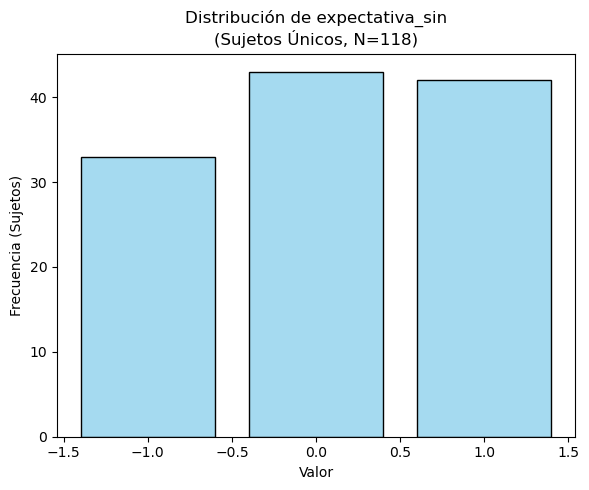


--- ANÁLISIS: TASA DE MANTIENE SEGÚN expectativa_sin ---



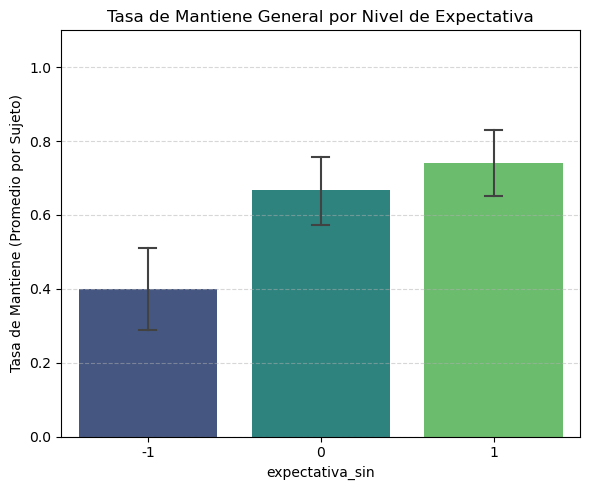


--- ANÁLISIS GENERAL POR TRATAMIENTO ---



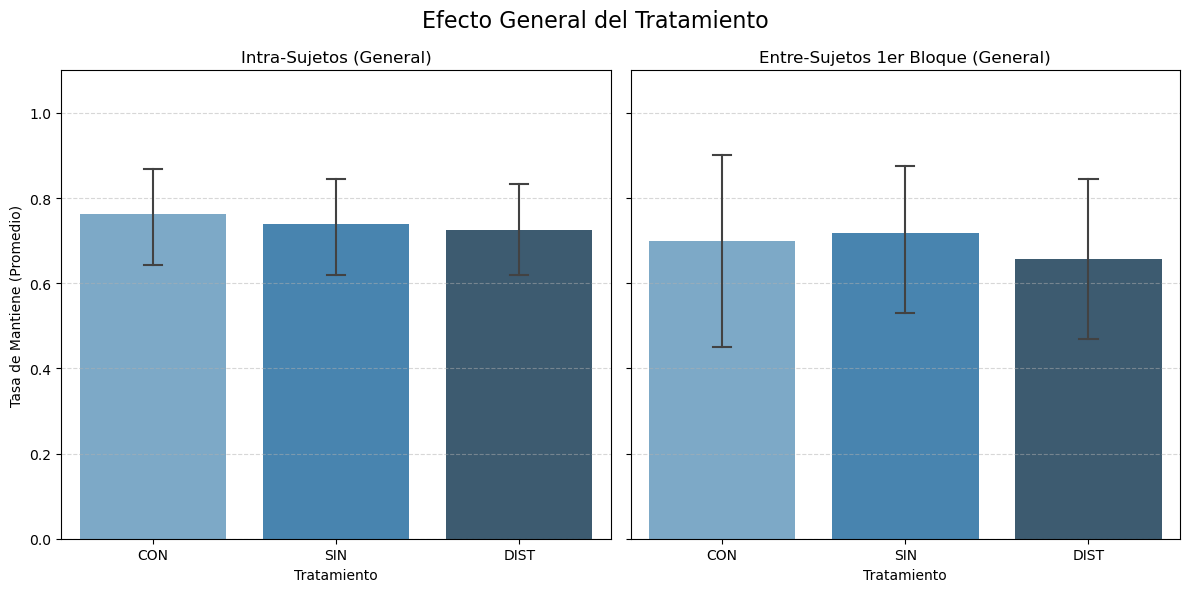


--- ANÁLISIS DE DIFERENCIAS (CON-SIN y SIN-DIST) ---



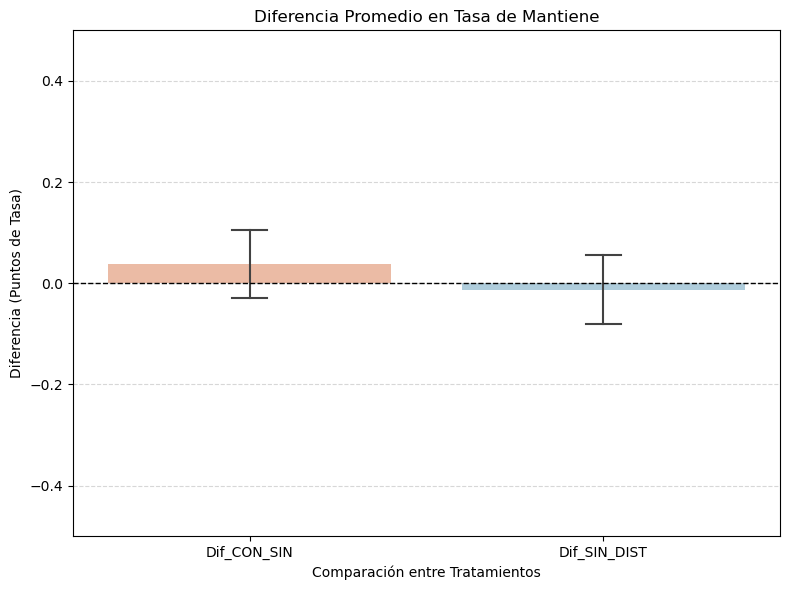

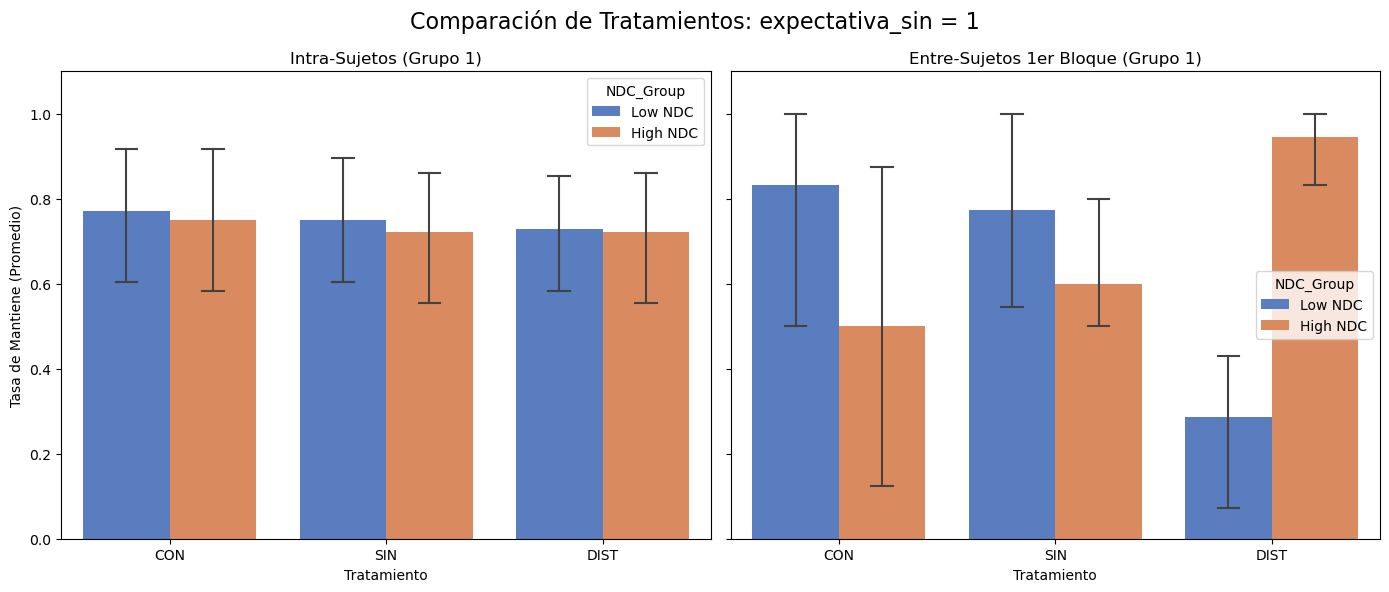

In [4]:
# --- VISUALIZACIONES ---
#-------------------- Expect4tiv4s  -------------------------------------------------------
# GRÁFICO 1: Distribución General de la Variable de Expectativa
plt.figure(figsize=(6, 5))
if COLUMNA_EXPECTATIVA in df_u.columns:
    sns.histplot(df_u[COLUMNA_EXPECTATIVA], discrete=True, kde=False, color='skyblue', shrink=0.8)
    plt.title(f'Distribución de {COLUMNA_EXPECTATIVA}\n(Sujetos Únicos, N={len(df_u)})')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia (Sujetos)')
    plt.tight_layout()
    plt.show()
else:
    print(f"Advertencia: {COLUMNA_EXPECTATIVA} no se encuentra en las columnas.")
    
#-------------------------------T4s4 de m4ntiene-----------------------------
print("\n" + "="*40)
print(f"--- ANÁLISIS: TASA DE MANTIENE SEGÚN {COLUMNA_EXPECTATIVA} ---")
print("="*40 + "\n")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(6, 5))

# Usamos barplot para mostrar la media + error estándar entre sujetos
sns.barplot(data=df_subj_mean, x=COLUMNA_EXPECTATIVA, y='Mantiene',
            capsize=0.1, errwidth=1.5, palette="viridis")

plt.title(f'Tasa de Mantiene General por Nivel de Expectativa')
plt.ylabel('Tasa de Mantiene (Promedio por Sujeto)')
plt.xlabel(COLUMNA_EXPECTATIVA)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
 
#-------------------- Tr4t4miento  -------------------------------------------------------
print("\n" + "="*40)
print("--- ANÁLISIS GENERAL POR TRATAMIENTO ---")
print("="*40 + "\n")


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# 5.1 Gráfico Intra-Sujetos (General)
sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene',
            order=orden_tratos, capsize=0.1, errwidth=1.5,
            palette="Blues_d", ax=axes[0]) # Usamos una paleta de azules
axes[0].set_title(f'Intra-Sujetos (General)')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Tasa de Mantiene (Promedio)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 5.2 Gráfico Entre-Sujetos (General)
sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene',
            order=orden_tratos, capsize=0.1, errwidth=1.5,
            palette="Blues_d", ax=axes[1])
axes[1].set_title(f'Entre-Sujetos 1er Bloque (General)')
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'Efecto General del Tratamiento', fontsize=16)
plt.tight_layout()
plt.show()

#----------------------- ANÁLISIS DE DIFERENCIAS--------------------
print("\n" + "="*40)
print("--- ANÁLISIS DE DIFERENCIAS (CON-SIN y SIN-DIST) ---")
print("="*40 + "\n")

plt.figure(figsize=(8, 6))

# Usamos barplot para ver la magnitud y dirección promedio del cambio
# Hue opcional: si quieres ver si el NDC afecta la magnitud del cambio, descomenta 'hue'
sns.barplot(data=df_deltas, x='Comparacion', y='Diferencia', 
            # hue='NDC_Group', # Descomentar para separar por grupo
            capsize=0.1, errwidth=1.5, palette="RdBu") 

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de referencia en 0
plt.title('Diferencia Promedio en Tasa de Mantiene')
plt.ylabel('Diferencia (Puntos de Tasa)')
plt.xlabel('Comparación entre Tratamientos')
plt.ylim(-0.5, 0.5) # Ajustar según tus datos si las barras son muy grandes/pequeñas
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
#---------------------------------NDC-------------------------------------------------------
# GRÁFICO 2: Paneles Intra vs Entre Sujetos (BARPLOT)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 2.1 Gráfico Intra-Sujetos (Barras)
# Cambiamos pointplot por barplot
sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', hue='NDC_Group',
            order=orden_tratos, capsize=0.1, errwidth=1.5,
            palette="muted", ax=axes[0])

axes[0].set_title(f'Intra-Sujetos (Grupo {VALOR_EXPECTATIVA})')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Tasa de Mantiene (Promedio)')

# 2.2 Gráfico Entre-Sujetos (Barras)
# Cambiamos pointplot por barplot
sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', hue='NDC_Group',
            order=orden_tratos, capsize=0.1, errwidth=1.5,
            palette="muted", ax=axes[1])

axes[1].set_title(f'Entre-Sujetos 1er Bloque (Grupo {VALOR_EXPECTATIVA})')
axes[1].set_ylabel('') # Ocultamos label Y para que quede más limpio al compartir eje

plt.suptitle(f'Comparación de Tratamientos: {COLUMNA_EXPECTATIVA} = {VALOR_EXPECTATIVA}', fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# --- TABLAS DE RESULTADOS ---

#-------------------- Expect4tiv4s  -------------------------------------------------------
# TABLA 1: Resumen General de la Variable de Expectativa
print(f"\n--- Resumen General de {COLUMNA_EXPECTATIVA} ---")
print(f"{'Valor':<10} | {'Estadísticas (Sujetos | Ensayos)'}")
print("-" * 50)

if COLUMNA_EXPECTATIVA in df_u.columns:
    conteos_subj = df_u[COLUMNA_EXPECTATIVA].value_counts().sort_index()
    pct_subj = (conteos_subj / len(df_u) * 100).round(1)
    conteos_trial = df.groupby(COLUMNA_EXPECTATIVA)['ID_Sujeto'].count().sort_index()

    for idx in conteos_subj.index:
        n_s = conteos_subj.loc[idx]
        p_s = pct_subj.loc[idx]
        n_t = conteos_trial.loc[idx] if idx in conteos_trial.index else 0
        print(f"{idx:<10} | {n_s} ({p_s}%) [Ensayos: {n_t}]")
        
#----------------------------------T4s4 de m4ntiene---------------------------
print(f"\n> Estadísticas Descriptivas (Agrupado por {COLUMNA_EXPECTATIVA}):")
tabla_exp = df_subj_mean.groupby(COLUMNA_EXPECTATIVA)['Mantiene'].agg(['count', 'mean', 'std', 'sem'])
print(tabla_exp.round(3))
print("-" * 50)
        
#-------------------- Tr4t4miento  -------------------------------------------------------
print(f"\n--- ESTADÍSTICAS GENERALES POR TRATAMIENTO ---")

print(f"\n> Tabla Intra-Sujetos (General):")
# Agrupamos solo por Tratamiento, ignorando NDC_Group
tabla_intra_gen = df_panel1.groupby(['Tratamiento'])['Mantiene'].agg(['count', 'mean', 'std', 'sem'])
print(tabla_intra_gen.reindex(orden_tratos).round(3))

print(f"\n> Tabla Entre-Sujetos (General - Primer Bloque):")
tabla_entre_gen = df_panel2.groupby(['Tratamiento'])['Mantiene'].agg(['count', 'mean', 'std', 'sem'])
print(tabla_entre_gen.reindex(orden_tratos).round(3))
print("-" * 50)

# ---------------------- Diferenci4s -----------------------------------------
print(f"\n> Estadísticas de las Diferencias (Deltas):")
tabla_deltas = df_deltas.groupby('Comparacion')['Diferencia'].agg(['count', 'mean', 'std', 'sem'])
# T-test de una muestra contra 0 para ver si la diferencia es significativa (opcional rápido)
from scipy.stats import ttest_1samp
p_values = df_deltas.groupby('Comparacion')['Diferencia'].apply(lambda x: ttest_1samp(x.dropna(), 0)[1])
tabla_deltas['p-value (vs 0)'] = p_values

print(tabla_deltas.round(4))
print("-" * 50)

#---------------------------------NDC-------------------------------------------------------
# TABLA 2: Estadísticas del Análisis Detallado (Intra y Entre Sujetos)
print(f"\n\n--- Estadísticas Detalladas (Expectativa = {VALOR_EXPECTATIVA}) ---")

print(f"\n> Tabla Intra-Sujetos (Agrupado por Tratamiento y NDC):")
print(df_panel1.groupby(['Tratamiento', 'NDC_Group'])['Mantiene']
      .agg(['count', 'mean', 'sem']).reindex(orden_tratos, level=0).round(3))

print(f"\n> Tabla Entre-Sujetos (1er Bloque - Agrupado por Tratamiento y NDC):")
print(df_panel2.groupby(['Tratamiento', 'NDC_Group'])['Mantiene']
      .agg(['count', 'mean', 'sem']).reindex(orden_tratos, level=0).round(3))
print("-" * 60)


--- Resumen General de expectativa_sin ---
Valor      | Estadísticas (Sujetos | Ensayos)
--------------------------------------------------
-1         | 33 (28.0%) [Ensayos: 198]
0          | 43 (36.4%) [Ensayos: 258]
1          | 42 (35.6%) [Ensayos: 252]

> Estadísticas Descriptivas (Agrupado por expectativa_sin):
                 count   mean    std    sem
expectativa_sin                            
-1                  33  0.399  0.348  0.061
 0                  43  0.667  0.311  0.047
 1                  42  0.742  0.295  0.046
--------------------------------------------------

--- ESTADÍSTICAS GENERALES POR TRATAMIENTO ---

> Tabla Intra-Sujetos (General):
             count   mean    std    sem
Tratamiento                            
CON             42  0.762  0.370  0.057
SIN             42  0.738  0.370  0.057
DIST            42  0.726  0.353  0.054

> Tabla Entre-Sujetos (General - Primer Bloque):
             count   mean    std    sem
Tratamiento                           